In [2]:
x = np.linspace(0, 10, 10)       # x-grid edges (11 for 10 cells)
y = np.linspace(0, 5, 6)         # y-grid edges (6 for 5 cells)
X, Y = np.meshgrid(x, y)         # create grid
Z = np.random.rand(6, 10)    

In [3]:
print(np.shape(Z))
print(np.shape(y))

(6, 10)
(6,)


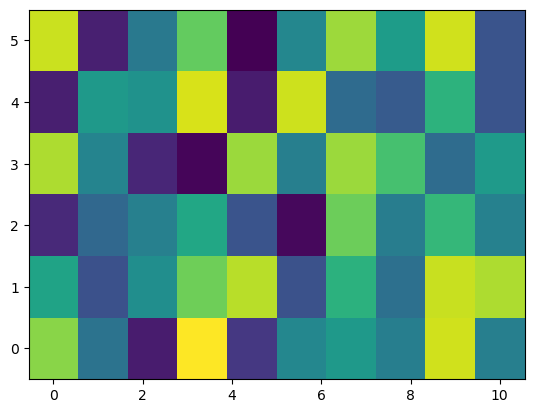

In [4]:
plt.pcolormesh(X, Y, Z, cmap='viridis', shading='auto')
# plt.tight_layout()

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import os, re, hashlib
from matplotlib import rcParams

# --- Font setup ---
rcParams['font.family'] = 'Times New Roman'
rcParams['mathtext.fontset'] = 'stix'
rcParams['axes.unicode_minus'] = False
rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 14,
    'legend.frameon': False,
})



# compute unique hash for x, y, Z, and labels
def compute_data_hash(x, y, Z, xlabel, ylabel, zlabel):
    """
    Compute a unique hash (SHA-256) for a dataset and its labels.
    Used to detect duplicate data so it won't be saved multiple times.
    """
    m = hashlib.sha256()
    m.update(np.array(x).tobytes())
    m.update(np.array(y).tobytes())
    m.update(np.array(Z).tobytes())
    for s in (xlabel, ylabel, zlabel):
        m.update(s.encode('utf-8'))
    return m.hexdigest()


def Plot3D(x, y, Z, xlabel='X', ylabel='Y', zlabel='Z',
           root_dir='D:\\testsave', cmap='viridis'):
    """
    Plot 2D pcolormesh in Jupyter and save only unique data to CSV.
    Each day has its own folder (YYYYMMDD), IDs start from 1.
    Avoids saving duplicate data by checking hash_log.txt.
    Even if data is duplicate, the plot still shows with ID.
    """

    # --- Validate array shapes ---
    x, y, Z = np.array(x), np.array(y), np.array(Z)
    if Z.shape != (len(y), len(x)):
        raise ValueError(f"Z shape {Z.shape} must be (len(y), len(x)) = ({len(y)}, {len(x)})")

    # --- Date setup ---
    today_raw = datetime.now()
    today_str = today_raw.strftime("%Y%m%d")       # for folder/file naming
    today_display = today_raw.strftime("%Y/%m/%d") # for plot title

    # --- Create date folder if not exists ---
    save_dir = os.path.join(root_dir, today_str)
    os.makedirs(save_dir, exist_ok=True)

    # --- Prepare duplicate-check log path ---
    hash_log_path = os.path.join(save_dir, "hash_log.txt")

    # --- Compute hash of the data ---
    data_hash = compute_data_hash(x, y, Z, xlabel, ylabel, zlabel)

    # --- Check if data was already saved today ---
    already_saved = False
    if os.path.exists(hash_log_path):
        with open(hash_log_path, 'r') as f:
            if data_hash in f.read():
                already_saved = True

    # --- Find plot ID number (incremental per day) ---
    existing_files = os.listdir(save_dir)
    pattern = re.compile(rf"{today_str}_ID(\d+)\.csv")
    ids_today = [int(m.group(1)) for f in existing_files if (m := pattern.search(f))]
    if already_saved:
        plot_id = max(ids_today, default=0)
    else:
        plot_id = max(ids_today, default=0) + 1

    # --- Create title and filename ---
    title = f"{today_display}: ID {plot_id}"
    csv_filename = os.path.join(save_dir, f"{today_str}_ID{plot_id}.csv")
 

    # --- Always plot, even if duplicate ---
    _showPlot3D(x, y, Z, xlabel, ylabel, zlabel, title, cmap)

    # --- If already saved, just show a message and stop ---
    if already_saved:
        return

    # --- Prepare DataFrame for CSV saving ---
    X_mesh, Y_mesh = np.meshgrid(x, y)
    df = pd.DataFrame({'x': X_mesh.ravel(), 'y': Y_mesh.ravel(), 'z': Z.ravel()})

    # --- Write metadata header + data ---
    header_lines = [
        f"# Generated on: {today_raw}",
        f"# Date: {today_display}",
        f"# ID: {plot_id}",
        f"# Data hash: {data_hash}",
        f"# xlabel: {xlabel}",
        f"# ylabel: {ylabel}",
        f"# zlabel: {zlabel}",
        f"# x range: {x[0]} to {x[-1]}, total {len(x)} points",
        f"# y range: {y[0]} to {y[-1]}, total {len(y)} points",
        "# ---------------------------------------------"
    ]
    with open(csv_filename, 'w', encoding='utf-8') as f:
        f.write("\n".join(header_lines) + "\n")
    df.to_csv(csv_filename, mode='a', index=False)

    # --- Log hash to avoid future duplicates ---
    with open(hash_log_path, 'a', encoding='utf-8') as f:
        f.write(data_hash + "\n")


# Plot function
def _showPlot3D(x, y, Z, xlabel, ylabel, zlabel, title, cmap):
    fig, ax = plt.subplots()
    mesh = ax.pcolormesh(x, y, Z, shading='auto', cmap=cmap)
    cbar = plt.colorbar(mesh, ax=ax)
    cbar.set_label(zlabel)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()



# ----- 2D line plot with duplicate-aware saving (same policy as Plot3D) -----
def Plot2D(x, y, Z, xlabel='X', ylabel='Y', zlabel='Z',
           root_dir='D:\\testsave', cmap='viridis',
           y_index=None, y_value=None):
    """
    Plot 2D line(s) from Z(x, y) in Jupyter and save CSV only if data is new.
    Folder structure is <root_dir>/<YYYYMMDD>/, IDs start from 1 per day.
    Duplicate detection uses compute_data_hash(x, y, Z, xlabel, ylabel, zlabel).

    Parameters
    ----------
    x, y : 1D arrays
        Coordinate ranges
    Z : 2D array
        z-values with shape (len(y), len(x))
    xlabel, ylabel, zlabel : str
        Labels; note the plot's y-axis uses zlabel
    root_dir : str
        Root output directory
    cmap : str
        Colormap for multi-curve coloring
    y_index : int, optional
        Plot a single row at this y index
    y_value : float, optional
        Plot the row whose y is closest to this value (ignored if y_index given)
    """

    # --- Validate arrays ---
    x, y, Z = np.array(x), np.array(y), np.array(Z)
    if Z.shape != (len(y), len(x)):
        raise ValueError(f"Z shape {Z.shape} must be (len(y), len(x)) = ({len(y)}, {len(x)})")

    # --- Date & folder setup ---
    today_raw = datetime.now()
    today_str = today_raw.strftime("%Y%m%d")        # for folder/file naming
    today_display = today_raw.strftime("%Y/%m/%d")  # for titles
    save_dir = os.path.join(root_dir, today_str)
    os.makedirs(save_dir, exist_ok=True)

    # --- Hash & duplicate check ---
    hash_log_path = os.path.join(save_dir, "hash_log.txt")
    data_hash = compute_data_hash(x, y, Z, xlabel, ylabel, zlabel)

    already_saved = False
    if os.path.exists(hash_log_path):
        with open(hash_log_path, 'r', encoding='utf-8') as f:
            if data_hash in f.read():
                already_saved = True

    # --- Determine plot ID (reuse last ID if duplicate; else increment) ---
    existing_files = os.listdir(save_dir)
    pattern = re.compile(rf"{today_str}_ID(\d+)\.csv")
    ids_today = [int(m.group(1)) for f in existing_files if (m := pattern.search(f))]
    if already_saved:
        plot_id = max(ids_today, default=0)  # reuse last ID of the day
    else:
        plot_id = max(ids_today, default=0) + 1

    # --- Title & CSV path ---
    title = f"{today_display}: ID {plot_id}"
    csv_filename = os.path.join(save_dir, f"{today_str}_ID{plot_id}.csv")

    # --- Plot (lines) ---
    _showPlot2D(x, y, Z, xlabel, ylabel, zlabel, title, cmap, y_index, y_value)

    # --- If duplicate, do not save again ---
    if already_saved:
        return

    # --- Save CSV (flat x,y,z) with metadata header ---
    X_mesh, Y_mesh = np.meshgrid(x, y)
    df = pd.DataFrame({'x': X_mesh.ravel(), 'y': Y_mesh.ravel(), 'z': Z.ravel()})

    header_lines = [
        f"# Generated on: {today_raw}",
        f"# Date: {today_display}",
        f"# ID: {plot_id}",
        f"# Data hash: {data_hash}",
        f"# xlabel: {xlabel}",
        f"# ylabel: {ylabel}",
        f"# zlabel: {zlabel}",
        f"# x range: {x[0]} to {x[-1]}, total {len(x)} points",
        f"# y range: {y[0]} to {y[-1]}, total {len(y)} points",
        "# ---------------------------------------------"
    ]
    with open(csv_filename, 'w', encoding='utf-8') as f:
        f.write("\n".join(header_lines) + "\n")
    df.to_csv(csv_filename, mode='a', index=False)

    # --- Log the hash to avoid future duplicates today ---
    with open(hash_log_path, 'a', encoding='utf-8') as f:
        f.write(data_hash + "\n")


def _showPlot2D(x, y, Z, xlabel, ylabel, zlabel, title, cmap, y_index=None, y_value=None):
    fig, ax = plt.subplots()

    # --- Handle y_index as single int or (start, end) range ---
    if y_index is not None:
        if isinstance(y_index, (list, tuple)) and len(y_index) == 2:
            start, end = y_index
            start = max(0, start)
            end = min(len(y), end)
            colors = plt.get_cmap(cmap)(np.linspace(0, 1, end - start))
            for i, idx in enumerate(range(start, end)):
                ax.plot(x, Z[idx, :], color=colors[i],
                        label=f"{ylabel}={y[idx]:.3g}")
        else:
            # single index
            idx = int(y_index)
            ax.plot(x, Z[idx, :], label=f"{ylabel} = {y[idx]:.3g}")

    elif y_value is not None:
        # plot nearest y-value
        idx = int(np.argmin(np.abs(y - y_value)))
        ax.plot(x, Z[idx, :], label=f"{ylabel} ≈ {y[idx]:.3g}")

    else:
        # plot all y rows
        colors = plt.get_cmap(cmap)(np.linspace(0, 1, len(y)))
        for i in range(len(y)):
            ax.plot(x, Z[i, :], color=colors[i], label=f"{ylabel}={y[i]:.3g}")

    # --- Labels and formatting ---
    ax.set_xlabel(xlabel)
    ax.set_ylabel(zlabel)
    ax.set_title(title)
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
    plt.tight_layout()
    plt.show()


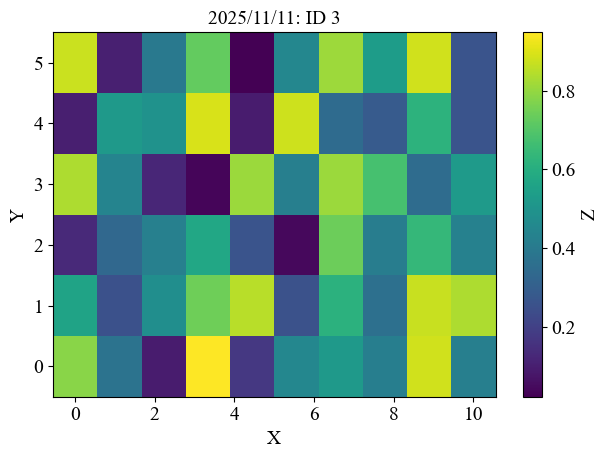

In [25]:
Plot3D(x,y,Z)

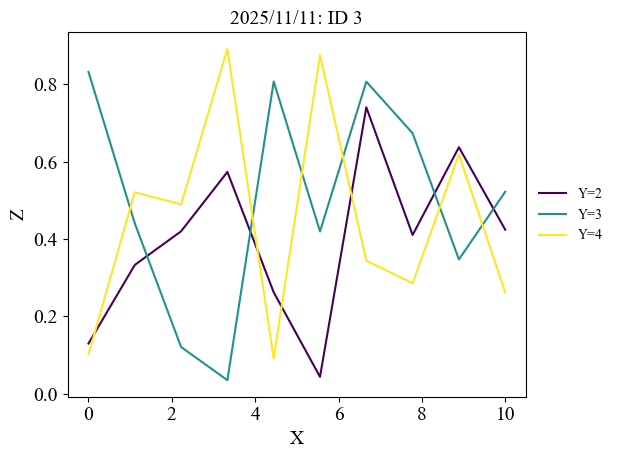

In [19]:
Plot2D(x,y,Z,y_index=[2,5])